## Data Preparation & Setup

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Templates for plots

# Set plotting style for presentation-ready outputs
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
# Load the dataset
df = pd.read_csv('amazon_delivery.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()

Dataset shape: (43739, 16)

Column types:
Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
dtype: object

First few rows:


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [4]:
# Data quality check
print("Missing values by column:")
print(df.isnull().sum())
print(f"\nUnique values in key columns:")
print(f"Vehicle types: {df['Vehicle'].unique()}")
print(f"Weather conditions: {df['Weather'].unique()}")
print(f"Traffic conditions: {df['Traffic'].unique()}")

Missing values by column:
Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

Unique values in key columns:
Vehicle types: ['motorcycle ' 'scooter ' 'van' 'bicycle ']
Weather conditions: ['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' nan]
Traffic conditions: ['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']


In [5]:
# Clean up the data
# Create clean working copy
amazon_df = df.copy()

# Convert all column names to lowercase
amazon_df.columns = amazon_df.columns.str.lower()

# Some category values have trailing spaces
# Remove leading and trailing spaces from category columns
amazon_df['weather'] = amazon_df['weather'].str.strip()
amazon_df['traffic'] = amazon_df['traffic'].str.strip()
amazon_df['vehicle'] = amazon_df['vehicle'].str.strip()
amazon_df['area'] = amazon_df['area'].str.strip()
amazon_df['category'] = amazon_df['category'].str.strip()

# there are 91 rows where the `Traffic` column values == 'NaN ' (a string rather than NaN)
amazon_df['traffic'] = amazon_df['traffic'].replace('NaN', 'Unknown')

# Handle missing values
amazon_df['weather'] = amazon_df['weather'].fillna('Unknown')
amazon_df['traffic'] = amazon_df['traffic'].fillna('Unknown')

# Convert to categorical for better analysis
amazon_df['vehicle'] = amazon_df['vehicle'].astype('category')
amazon_df['weather'] = amazon_df['weather'].astype('category')
amazon_df['traffic'] = amazon_df['traffic'].astype('category')

print("Data preparation completed.")
print(f"Final dataset shape: {amazon_df.shape}")

Data preparation completed.
Final dataset shape: (43739, 16)


## 1. Vehicle Delivery Time Analysis

In [6]:
# Overall vehicle delivery time summary
vehicle_summary = amazon_df.groupby('vehicle')['delivery_time'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

vehicle_summary.columns = ['Count', 'Mean_Time', 'Median_Time', 'Std_Dev', 'Min_Time', 'Max_Time']
print("Vehicle Performance Summary:")
print(vehicle_summary)

# Calculate vehicle utilization
vehicle_utilization = amazon_df['vehicle'].value_counts(normalize=True) * 100
print(f"\nVehicle Utilization (%):")
for vehicle, pct in vehicle_utilization.items():
    print(f"{vehicle}: {pct:.1f}%")

Vehicle Performance Summary:
            Count  Mean_Time  Median_Time  Std_Dev  Min_Time  Max_Time
vehicle                                                               
bicycle        15     127.00        125.0    37.31        60       195
motorcycle  25527     131.03        130.0    53.64        10       270
scooter     14639     116.36        115.0    48.19        10       245
van          3558     116.14        115.0    47.78        10       245

Vehicle Utilization (%):
motorcycle: 58.4%
scooter: 33.5%
van: 8.1%
bicycle: 0.0%


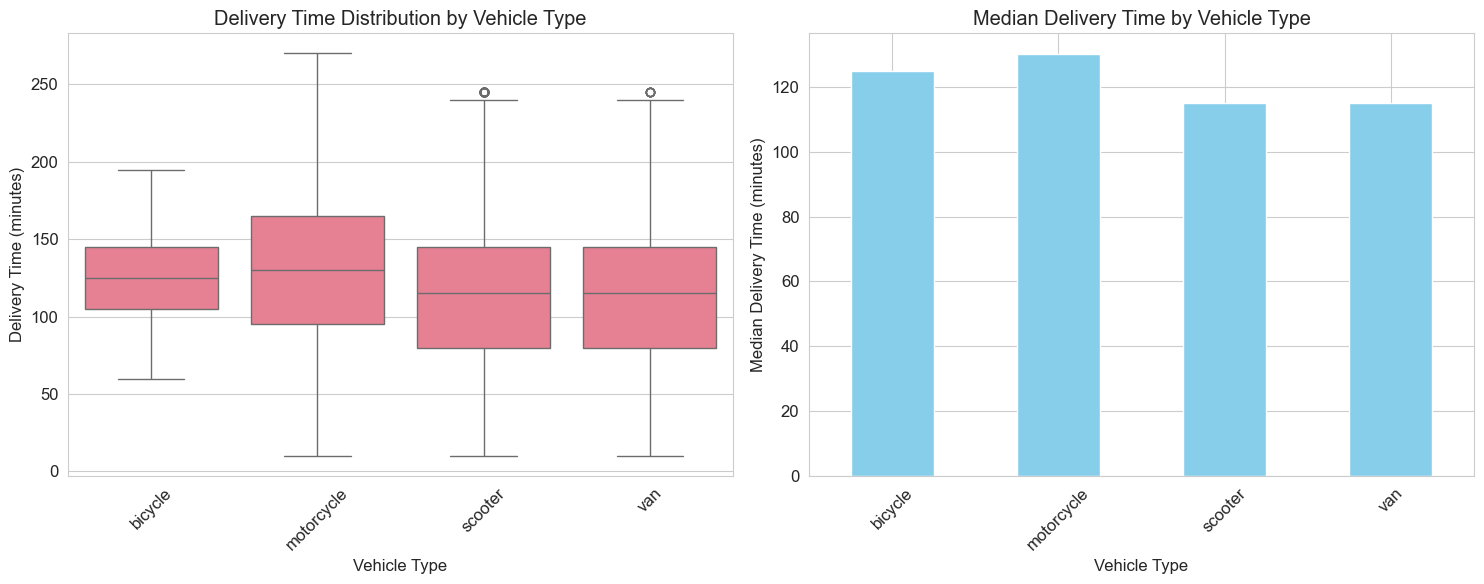

In [7]:
# PLOT 1: Vehicle Performance Overview
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Box plot of delivery times by vehicle
sns.boxplot(data=amazon_df, x='vehicle', y='delivery_time', ax=ax1, order=sorted(amazon_df['vehicle'].unique()))

ax1.set_title('Delivery Time Distribution by Vehicle Type')
ax1.set_xlabel('Vehicle Type')
ax1.set_ylabel('Delivery Time (minutes)')
ax1.tick_params(axis='x', rotation=45)

# Bar plot of median delivery times
median_times = (
    amazon_df
    .groupby('vehicle')['delivery_time']
    .median()
    .sort_index()   # alphabetical by vehicle
)
median_times.plot(kind='bar', ax=ax2, color='skyblue')
ax2.set_title('Median Delivery Time by Vehicle Type')
ax2.set_xlabel('Vehicle Type')
ax2.set_ylabel('Median Delivery Time (minutes)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('01_vehicle_delivery_time_overview.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Weather Impact on delivery times

In [8]:
# Weather impact analysis on delivery times
weather_vehicle_summary = amazon_df.groupby(['vehicle', 'weather'])['delivery_time'].agg([
    'count', 'mean', 'median'
]).round(2)

print("Vehicle Performance by Weather Condition:")
print(weather_vehicle_summary)

# Create pivot table for easier comparison
weather_pivot = amazon_df.pivot_table(
    values='delivery_time', 
    index='vehicle', 
    columns='weather', 
    aggfunc='median'
).round(2)

print(f"\nMedian Delivery Times - Vehicle vs Weather:")
print(weather_pivot)

Vehicle Performance by Weather Condition:
                       count    mean  median
vehicle    weather                          
bicycle    Cloudy          0     NaN     NaN
           Fog             0     NaN     NaN
           Sandstorms      0     NaN     NaN
           Stormy          0     NaN     NaN
           Sunny           0     NaN     NaN
           Unknown        15  127.00   125.0
           Windy           0     NaN     NaN
motorcycle Cloudy       4229  142.24   140.0
           Fog          4329  140.65   140.0
           Sandstorms   4246  130.43   130.0
           Stormy       4307  129.52   130.0
           Sunny        4139  111.83   105.0
           Unknown         8  133.12   140.0
           Windy        4269  130.88   130.0
scooter    Cloudy       2472  133.19   135.0
           Fog          2483  131.22   135.0
           Sandstorms   2433  113.20   120.0
           Stormy       2473  114.39   120.0
           Sunny        2367   92.00    90.0
           Un

Number of 'Unknown' weather observations: 91


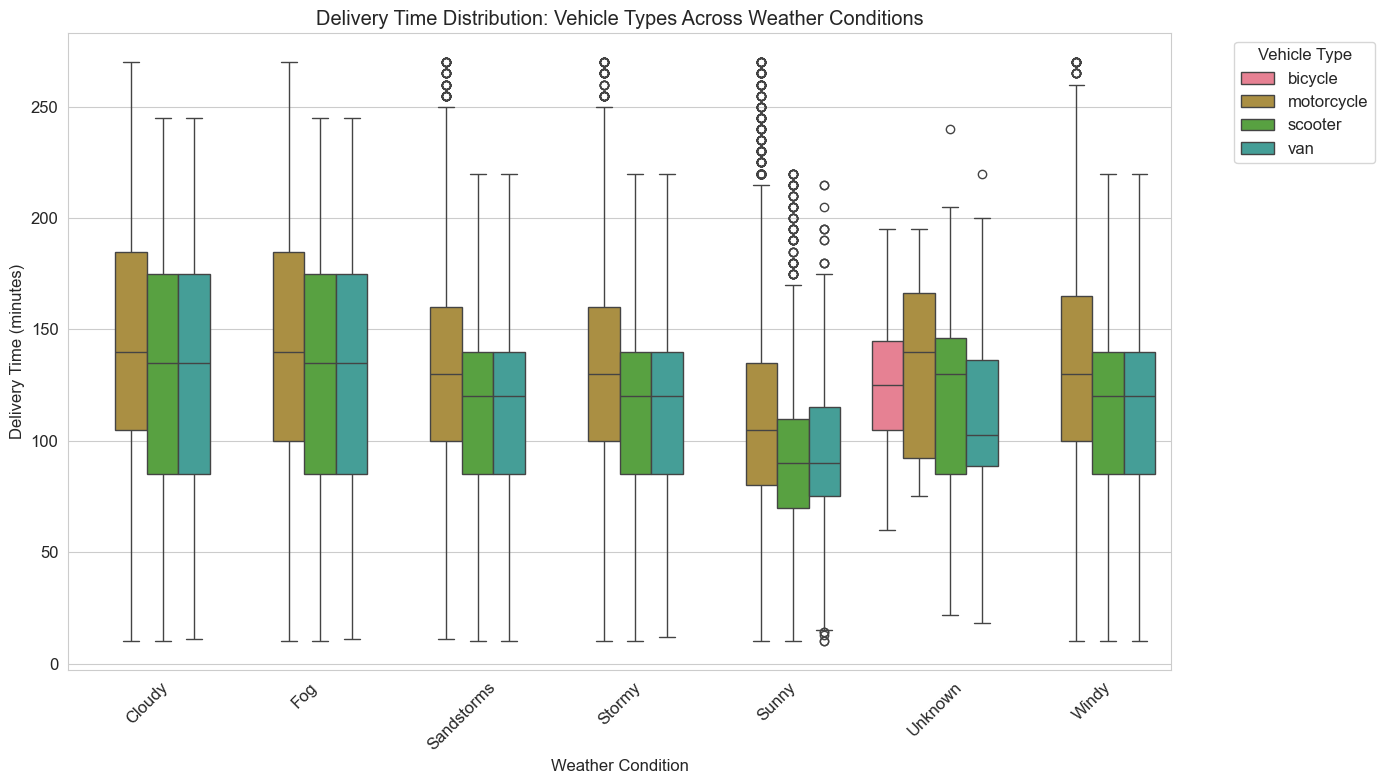

In [9]:
print(f"Number of 'Unknown' weather observations: {len(amazon_df[amazon_df['weather'] == 'Unknown'])}")
# PLOT 2: Vehicle Delivery Times Across Weather Conditions
plt.figure(figsize=(14, 8))
sns.boxplot(data=amazon_df, x='weather', y='delivery_time', hue='vehicle')
plt.title('Delivery Time Distribution: Vehicle Types Across Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Delivery Time (minutes)')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('02a_vehicle_weather_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

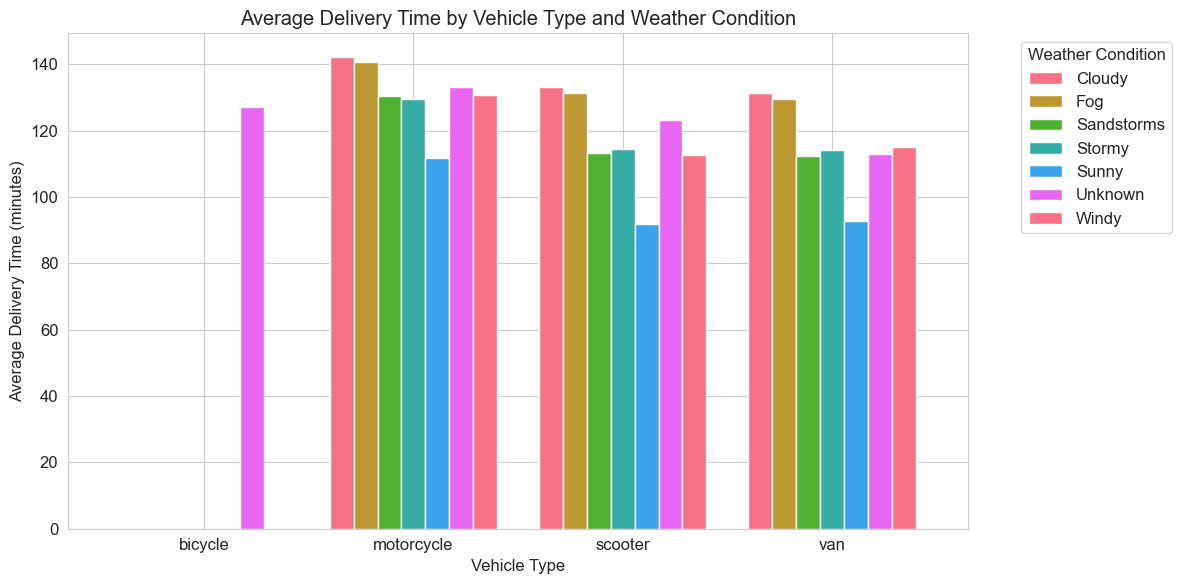

In [10]:
# PLOT 3: Weather Impact Summary
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate mean delivery time by vehicle and weather
weather_means = amazon_df.groupby(['vehicle', 'weather'])['delivery_time'].mean().unstack()
weather_means.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Delivery Time by Vehicle Type and Weather Condition')
ax.set_xlabel('Vehicle Type')
ax.set_ylabel('Average Delivery Time (minutes)')
ax.legend(title='Weather Condition', bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('02b_vehicle_weather_bar.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Traffic Impact on Vehicle Delivery Times

In [11]:
# Traffic impact on delivery times by vehicle
traffic_vehicle_summary = amazon_df.groupby(['vehicle', 'traffic'])['delivery_time'].agg([
    'count', 'mean', 'median'
]).round(2)

print("Vehicle Performance by Traffic Condition:")
print(traffic_vehicle_summary)

# Create pivot table for easier comparison
traffic_pivot = amazon_df.pivot_table(
    values='delivery_time', 
    index='vehicle', 
    columns='traffic', 
    aggfunc='median'
).round(2)

print(f"\nMedian Delivery Times - Vehicle vs Traffic:")
print(traffic_pivot)

Vehicle Performance by Traffic Condition:
                    count    mean  median
vehicle    traffic                       
bicycle    High         0     NaN     NaN
           Jam          0     NaN     NaN
           Low          0     NaN     NaN
           Medium       0     NaN     NaN
           Unknown     15  127.00   125.0
motorcycle High      2529  136.93   140.0
           Jam       7960  155.63   155.0
           Low       8821  105.70   105.0
           Medium    6209  133.06   135.0
           Unknown      8  133.12   140.0
scooter    High      1429  118.25   125.0
           Jam       4625  137.51   140.0
           Low       4999   95.18    90.0
           Medium    3554  117.81   120.0
           Unknown     32  123.34   130.0
van        High       338  120.55   130.0
           Jam       1140  134.37   135.0
           Low       1179   95.05    90.0
           Medium     865  119.25   120.0
           Unknown     36  112.89   102.5

Median Delivery Times - Vehicle v

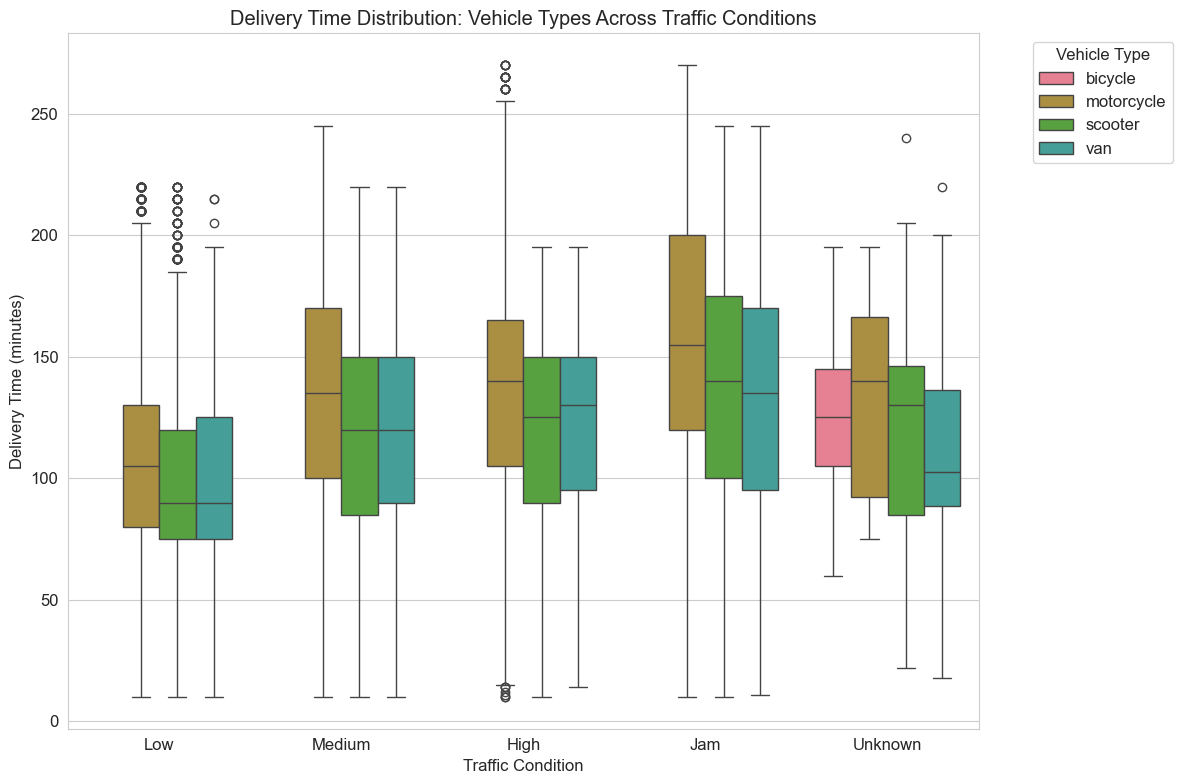

In [12]:
# PLOT 4: Vehicle Delivery Times Across Traffic Conditions
traffic_order = ["Low", "Medium", "High", "Jam", "Unknown"]

plt.figure(figsize=(12, 8))
sns.boxplot(data=amazon_df, x='traffic', y='delivery_time', hue='vehicle', order=traffic_order)
plt.title('Delivery Time Distribution: Vehicle Types Across Traffic Conditions')
plt.xlabel('Traffic Condition')
plt.ylabel('Delivery Time (minutes)')
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('03a_vehicle_traffic_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

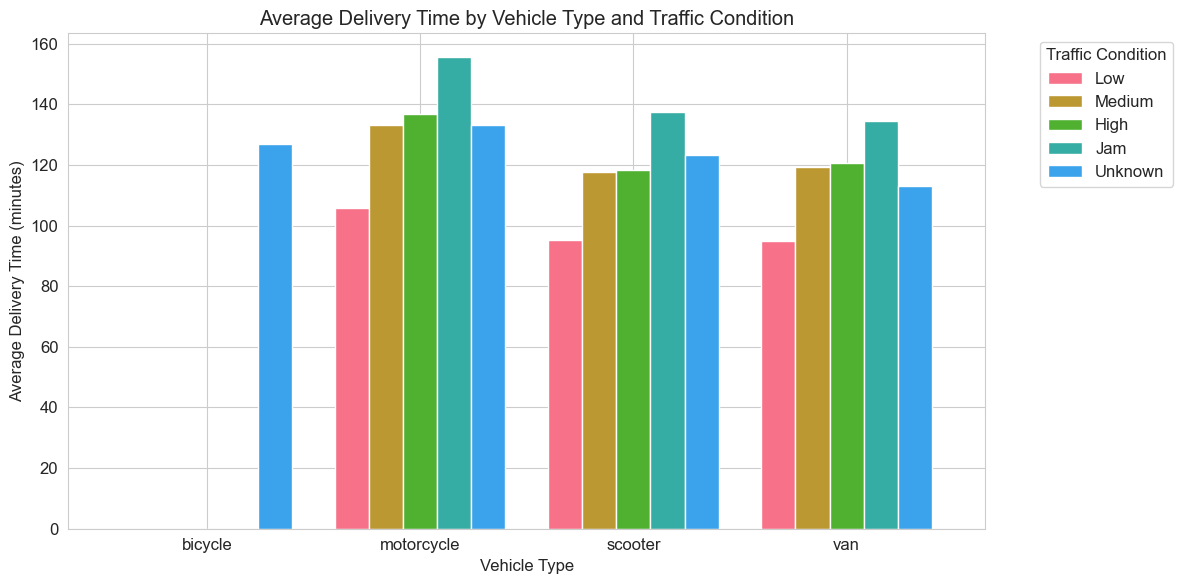

In [13]:
# PLOT 5: Traffic Comparisons
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate mean delivery time by vehicle and traffic
traffic_means = amazon_df.groupby(['vehicle', 'traffic'])['delivery_time'].mean().unstack().reindex(columns=traffic_order)
traffic_means.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Average Delivery Time by Vehicle Type and Traffic Condition')
ax.set_xlabel('Vehicle Type')
ax.set_ylabel('Average Delivery Time (minutes)')
ax.legend(title='Traffic Condition', bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('03b_vehicle_traffic_bar.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Combined Weather & Traffic Analysis

In [14]:
# Combined conditions analysis
combined_summary = amazon_df.groupby(['vehicle', 'weather', 'traffic'])['delivery_time'].agg([
    'count', 'mean', 'median'
]).round(2)

# Filter combinations with sufficient data (at least 10 observations)
significant_combinations = combined_summary[combined_summary['count'] >= 10]
print("Vehicle Performance by Combined Conditions (min 10 observations):")
print(significant_combinations.head(25))

# Find best and worst performing combinations for each vehicle
print(f"\n=== OPTIMAL CONDITIONS BY VEHICLE ===")
for vehicle in amazon_df['vehicle'].unique():
    '''
    index.get_level_values(0)
    This method is specific to MultiIndex (hierarchical index) DataFrames and extracts values from a particular level of the index hierarchy.
    The significant_combinations DataFrame has a 3-level MultiIndex structure:
    Level 0 (vehicle): ['Bike', 'Car', 'Motorcycle', 'Scooter', 'Truck']
    '''
    vehicle_data = significant_combinations[significant_combinations.index.get_level_values(0) == vehicle]
    if not vehicle_data.empty:
        best_combo = vehicle_data['mean'].idxmin()
        worst_combo = vehicle_data['mean'].idxmax()
        print(f"\n{vehicle.upper()}:")
        print(f"  Best: {best_combo[1]} + {best_combo[2]} (avg: {vehicle_data.loc[best_combo, 'mean']:.1f} min)")
        print(f"  Worst: {worst_combo[1]} + {worst_combo[2]} (avg: {vehicle_data.loc[worst_combo, 'mean']:.1f} min)")

Vehicle Performance by Combined Conditions (min 10 observations):
                               count    mean  median
vehicle    weather    traffic                       
bicycle    Unknown    Unknown     15  127.00   125.0
motorcycle Cloudy     High       404  136.35   140.0
                      Jam       1346  175.12   182.5
                      Low       1470  111.77   105.0
                      Medium    1009  145.11   150.0
           Fog        High       448  132.11   135.0
                      Jam       1370  176.12   185.0
                      Low       1493  110.47   105.0
                      Medium    1018  140.93   150.0
           Sandstorms High       404  141.98   145.0
                      Jam       1335  152.40   155.0
                      Low       1483  101.98   105.0
                      Medium    1024  138.42   140.0
           Stormy     High       429  142.17   145.0
                      Jam       1272  153.08   155.0
                      Low       1

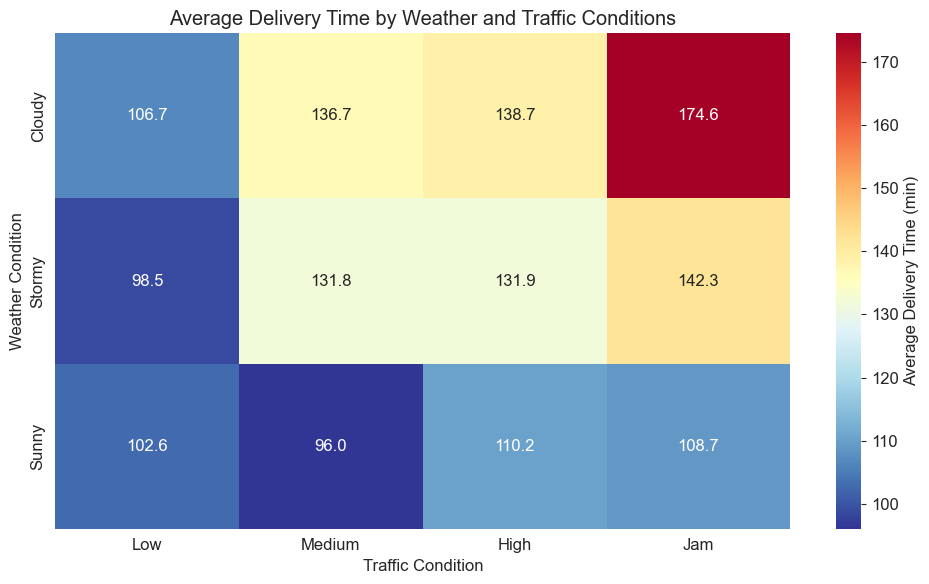

In [15]:
# PLOT 6: Combined Conditions Heatmap
# Create a heatmap for main traffic-weather combinations
main_conditions = amazon_df[
    (amazon_df['vehicle'] != 'bicycle') & 
    (amazon_df['weather'].isin(['Sunny', 'Cloudy',' Fog', 'Stormy'])) & 
    (amazon_df['traffic'].isin(['Low', 'Medium', 'High', 'Jam'])) 
]

# Define the desired traffic order
traffic_order = ['Low', 'Medium', 'High', 'Jam']

# Convert traffic column to ordered categorical
main_conditions['traffic'] = pd.Categorical(
    main_conditions['traffic'],
    categories=traffic_order,
    ordered=True
)

# Create pivot table for heatmap
condition_pivot = main_conditions.pivot_table(
    values='delivery_time', 
    index=['weather'], 
    columns=['traffic'], 
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
'''
annot=True - Shows the actual numerical values inside each heatmap cell

cmap='RdYlBu_r' - Color map using Red-Yellow-Blue reversed palette:
    Red = higher values (longer delivery times)
    Blue = lower values (shorter delivery times)
    The _r suffix reverses the color scale

fmt='.1f' - Number formatting for annotations:
    .1f = one decimal place
    Example: 25.7 instead of 25.666667

cbar_kws={'label': 'Average Delivery Time (min)'} - Customizes the color bar:
    Adds a descriptive label to explain what the colors represent
    Makes the visualization self-explanatory
'''
sns.heatmap(condition_pivot, annot=True, cmap='RdYlBu_r', fmt='.1f', cbar_kws={'label': 'Average Delivery Time (min)'})
plt.title('Average Delivery Time by Weather and Traffic Conditions')
plt.xlabel('Traffic Condition')
plt.ylabel('Weather Condition')
plt.tight_layout()
plt.savefig('04a_combined_conditions_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

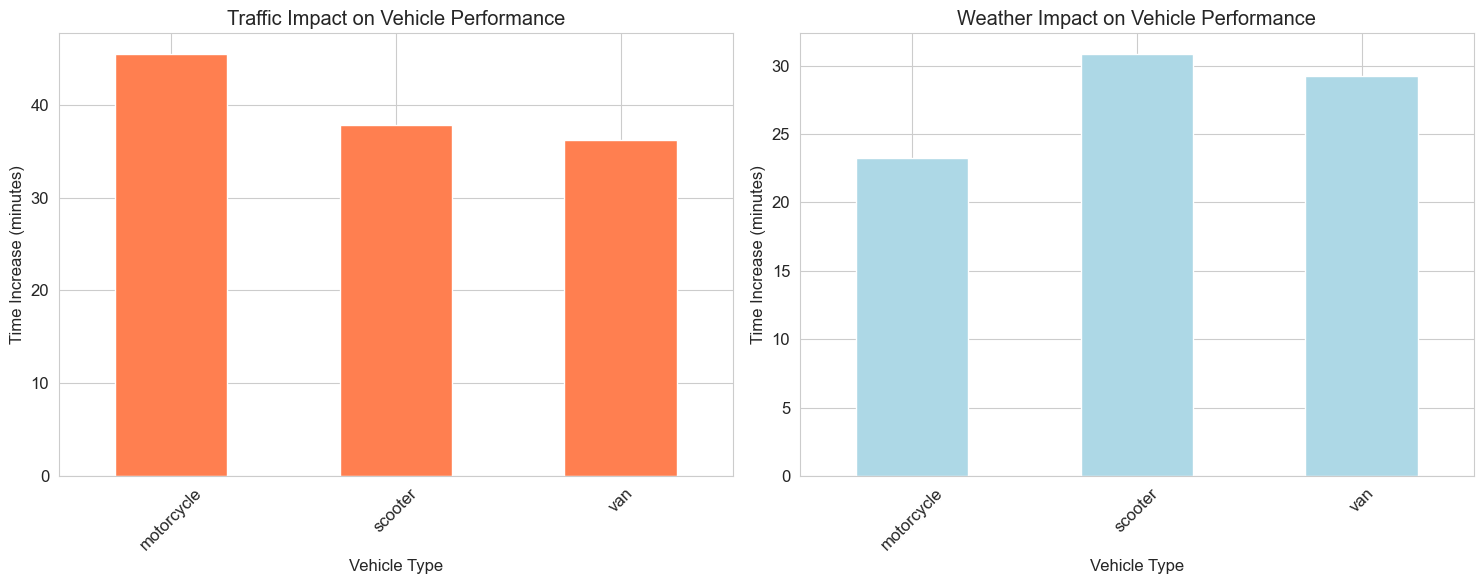

Vehicle Efficiency Analysis:
      Vehicle  Low_Traffic_Time  High_Traffic_Time  Sunny_Weather_Time  \
0  motorcycle            105.70             151.12              111.83   
1     scooter             95.18             132.96               92.00   
2         van             95.05             131.21               92.84   

   Bad_Weather_Time  Traffic_Impact  Weather_Impact  
0            135.10           45.42           23.27  
1            122.82           37.78           30.82  
2            122.12           36.16           29.28  


In [16]:
# PLOT 7: Vehicle Efficiency Rankings
# Calculate efficiency score for each vehicle under different conditions
vehicles = amazon_df[amazon_df['vehicle'] != 'bicycle']['vehicle'].unique()
efficiency_data = []
for vehicle in vehicles:
    vehicle_df = amazon_df[amazon_df['vehicle'] == vehicle]
    
    # Calculate average delivery time under optimal vs challenging conditions
    low_traffic = vehicle_df[vehicle_df['traffic'] == 'Low']['delivery_time'].mean()
    high_traffic = vehicle_df[vehicle_df['traffic'].isin(['High', 'Jam'])]['delivery_time'].mean()
    
    sunny_weather = vehicle_df[vehicle_df['weather'] == 'Sunny']['delivery_time'].mean()
    bad_weather = vehicle_df[vehicle_df['weather'].isin(['Stormy', 'Fog'])]['delivery_time'].mean()
    
    efficiency_data.append({
        'Vehicle': vehicle,
        'Low_Traffic_Time': low_traffic,
        'High_Traffic_Time': high_traffic,
        'Sunny_Weather_Time': sunny_weather,
        'Bad_Weather_Time': bad_weather,
        'Traffic_Impact': high_traffic - low_traffic if pd.notna(high_traffic) and pd.notna(low_traffic) else 0,
        'Weather_Impact': bad_weather - sunny_weather if pd.notna(bad_weather) and pd.notna(sunny_weather) else 0
    })

efficiency_df = pd.DataFrame(efficiency_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Traffic impact comparison
efficiency_df.set_index('Vehicle')['Traffic_Impact'].plot(kind='bar', ax=ax1, color='coral')
ax1.set_title('Traffic Impact on Vehicle Performance')
ax1.set_ylabel('Time Increase (minutes)')
ax1.set_xlabel('Vehicle Type')
ax1.tick_params(axis='x', rotation=45)

# Weather impact comparison
efficiency_df.set_index('Vehicle')['Weather_Impact'].plot(kind='bar', ax=ax2, color='lightblue')
ax2.set_title('Weather Impact on Vehicle Performance')
ax2.set_ylabel('Time Increase (minutes)')
ax2.set_xlabel('Vehicle Type')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('04b_vehicle_efficiency_rankings.png', dpi=300, bbox_inches='tight')
plt.show()

print("Vehicle Efficiency Analysis:")
print(efficiency_df.round(2))

## 5. Where are the stores?

In [17]:
# Filter out invalid coordinates
valid_stores = amazon_df[
    (amazon_df['store_latitude'] != 0) & 
    (amazon_df['store_longitude'] != 0)
]

print(f"Valid store coordinates: {len(valid_stores)}")
print(f"Invalid coordinates filtered out: {len(amazon_df) - len(valid_stores)}")

Valid store coordinates: 40234
Invalid coordinates filtered out: 3505


In [18]:
# Group delivery counts per unique store location
store_summary = valid_stores.groupby(['store_latitude', 'store_longitude']).agg({
    'delivery_time': ['count', 'mean', 'median']
}).round(2)

# Flatten column names
store_summary.columns = ['delivery_count', 'avg_delivery_time', 'median_delivery_time']
store_summary = store_summary.reset_index()

print(f"Unique store locations: {len(store_summary)}")
print(f"\nTop 10 stores by delivery volume:")
print(store_summary.nlargest(10, 'delivery_count')[['store_latitude', 'store_longitude', 'delivery_count']])

Unique store locations: 521

Top 10 stores by delivery volume:
     store_latitude  store_longitude  delivery_count
470       26.911378        75.789034             175
475       26.914142        75.805704             174
465       26.902908        75.792934             171
464       26.902328        75.794257             170
461       26.888420        75.800689             168
463       26.892312        75.806896             168
466       26.902940        75.793007             168
473       26.913726        75.752820             168
458       26.766536        75.837333             167
472       26.913483        75.803139             167


In [19]:
# Create folium heatmap of store delivery volumes
# Center map on India (approximate geographic center)
map_center = [20.5937, 78.9629]
store_map = folium.Map(location=map_center, zoom_start=5, tiles='OpenStreetMap')

# Prepare data for heatmap - [latitude, longitude, weight]
heat_data = []
for _, row in store_summary.iterrows():
    heat_data.append([
        row['store_latitude'], 
        row['store_longitude'], 
        row['delivery_count']
    ])

# Add heatmap layer
HeatMap(
    heat_data,
    min_opacity=0.2,
    max_zoom=18,
    radius=15,
    blur=10,
    gradient={0.2: 'blue', 0.4: 'purple', 0.6: 'orange', 1: 'red'}
).add_to(store_map)

# Add markers with delivery counts for each store
for _, row in store_summary.iterrows():
    # Create a marker with the delivery count displayed
    folium.CircleMarker(
        location=[row['store_latitude'], row['store_longitude']],
        radius=6,
        color=None,
        fill=True,
        fill_opacity=0.0,  # invisible circle, popup only
        popup=f"Deliveries: {int(row['delivery_count'])}"
    ).add_to(store_map)

# Add title
store_map.get_root().html.add_child(
    folium.Element(
        '<h3 style="text-align: center; color: #2E8B57; font-family: Arial, sans-serif;">' +
        'Store Delivery Volume Heatmap with Delivery Counts</h3>'
    )
)

print("Interactive store heatmap created successfully!")
print(f"Total delivery locations: {len(heat_data)}")
print(f"Added individual markers showing delivery counts for each store")
store_map

Interactive store heatmap created successfully!
Total delivery locations: 521
Added individual markers showing delivery counts for each store


In [20]:
# Save the folium map as an HTML file
store_map.save('05_store_delivery_heatmap.html')

## 6. Business Insights

In [21]:
# Generate key insights summary
print("=== KEY FINDINGS SUMMARY ===")
print("\n1. OVERALL VEHICLE PERFORMANCE:")
overall_ranking = amazon_df.groupby('vehicle')['delivery_time'].median().sort_values()
for i, (vehicle, time) in enumerate(overall_ranking.items(), 1):
    print(f"   {i}. {vehicle}: {time:.1f} minutes (median)")

print("\n2. WEATHER RESILIENCE:")
for vehicle in amazon_df['vehicle'].unique():
    vehicle_weather = amazon_df[amazon_df['vehicle'] == vehicle].groupby('weather')['delivery_time'].median()
    if len(vehicle_weather) > 1:
        variance = vehicle_weather.max() - vehicle_weather.min()
        best_weather = vehicle_weather.idxmin()
        if (best_weather == 'Unknown'):
            print(f"   {vehicle}: {variance:.1f}min range (best in {best_weather} - not helpful)")
        else:
            print(f"   {vehicle}: {variance:.1f}min range (best in {best_weather})")

print("\n3. TRAFFIC ADAPTABILITY:")
for vehicle in amazon_df['vehicle'].unique():
    vehicle_traffic = amazon_df[amazon_df['vehicle'] == vehicle].groupby('traffic')['delivery_time'].median()
    if (len(vehicle_traffic) > 1):
        variance = vehicle_traffic.max() - vehicle_traffic.min()
        best_traffic = vehicle_traffic.idxmin()
        if (best_traffic == 'Unknown'):
            print(f"   {vehicle}: {variance:.1f}min range (best in {best_traffic} - not helpful)")
        else:
            print(f"   {vehicle}: {variance:.1f}min range (best in {best_traffic})")

=== KEY FINDINGS SUMMARY ===

1. OVERALL VEHICLE PERFORMANCE:
   1. scooter: 115.0 minutes (median)
   2. van: 115.0 minutes (median)
   3. bicycle: 125.0 minutes (median)
   4. motorcycle: 130.0 minutes (median)

2. WEATHER RESILIENCE:
   motorcycle: 35.0min range (best in Sunny)
   scooter: 45.0min range (best in Sunny)
   van: 45.0min range (best in Sunny)
   bicycle: 0.0min range (best in Unknown - not helpful)

3. TRAFFIC ADAPTABILITY:
   motorcycle: 50.0min range (best in Low)
   scooter: 50.0min range (best in Low)
   van: 45.0min range (best in Low)
   bicycle: 0.0min range (best in Unknown - not helpful)
